# ASSIGNMENT 12 - RANDOM FOREST

In [12]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE  # Handling imbalance

from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [13]:
# Load the dataset
data = pd.read_csv('glass.csv')

# Display first 5 rows
print("First 5 rows of the dataset:")
print(data.head())

First 5 rows of the dataset:
        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1


In [14]:
print("\nDataset Info:")
print(data.info())

print("\nDataset Description:")
print(data.describe())

# Check for missing values
print("\nMissing Values in Dataset:")
print(data.isnull().sum())

# Check class distribution
print("\nGlass Type Distribution:")
print(data['Type'].value_counts())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB
None

Dataset Description:
               RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056   
std      0.003037    0.816604    1.442408    0.499270    0.774546    0.652192   
min      1.511150   10.730000    0

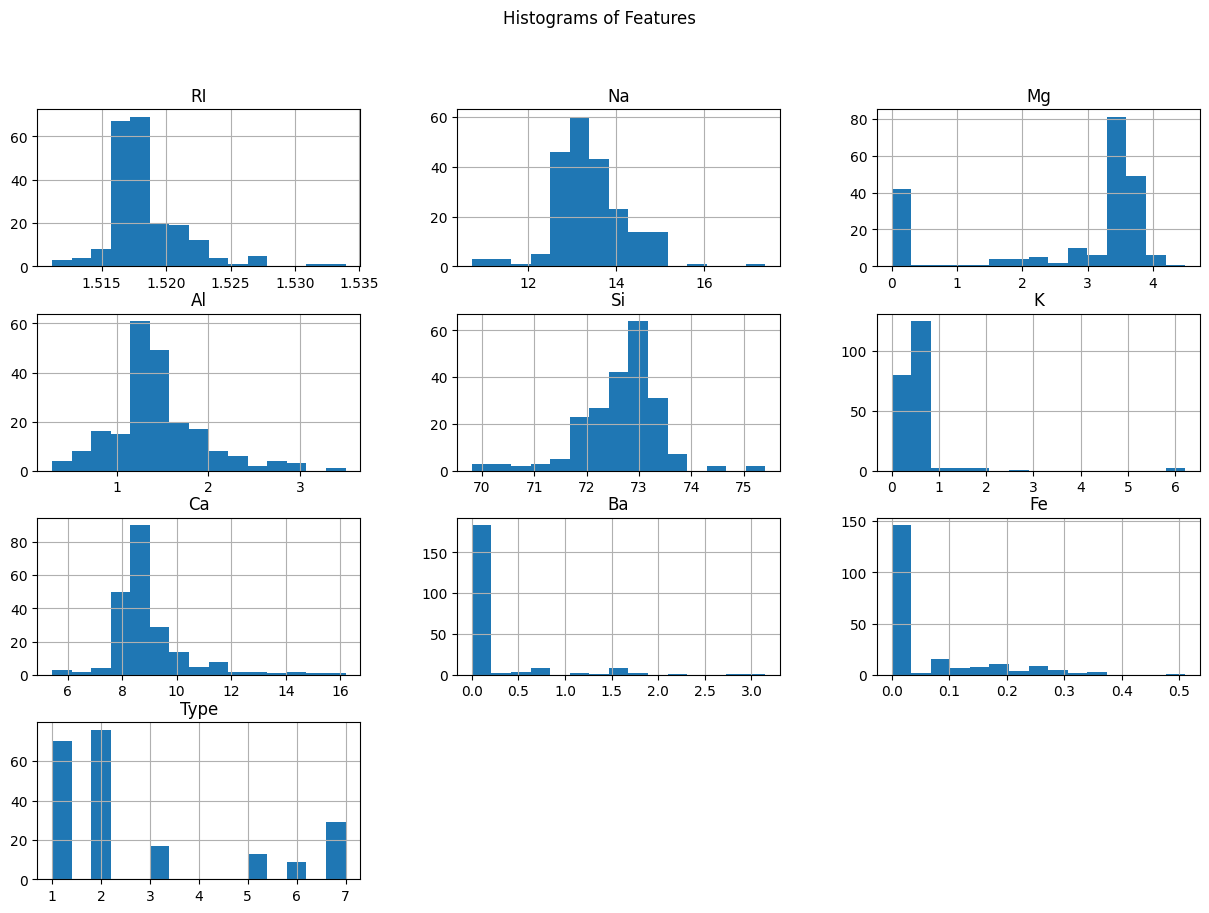

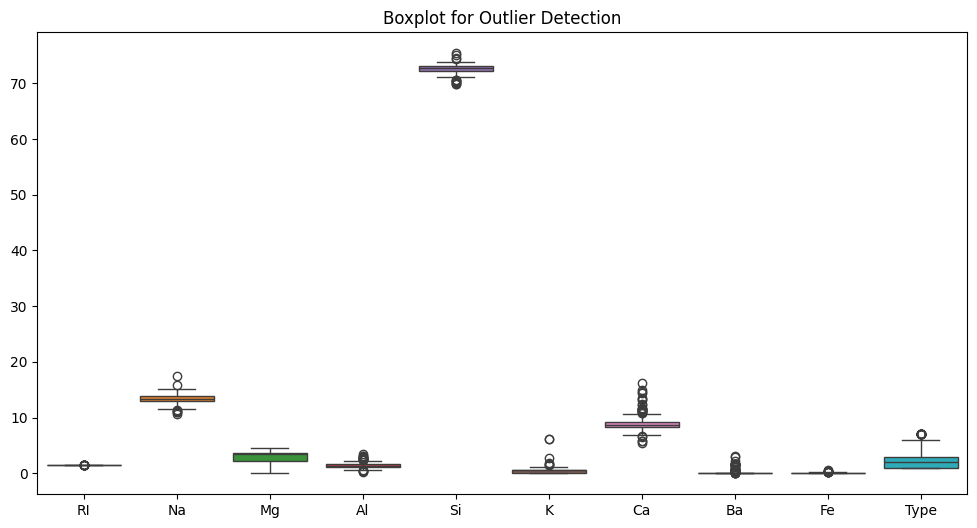

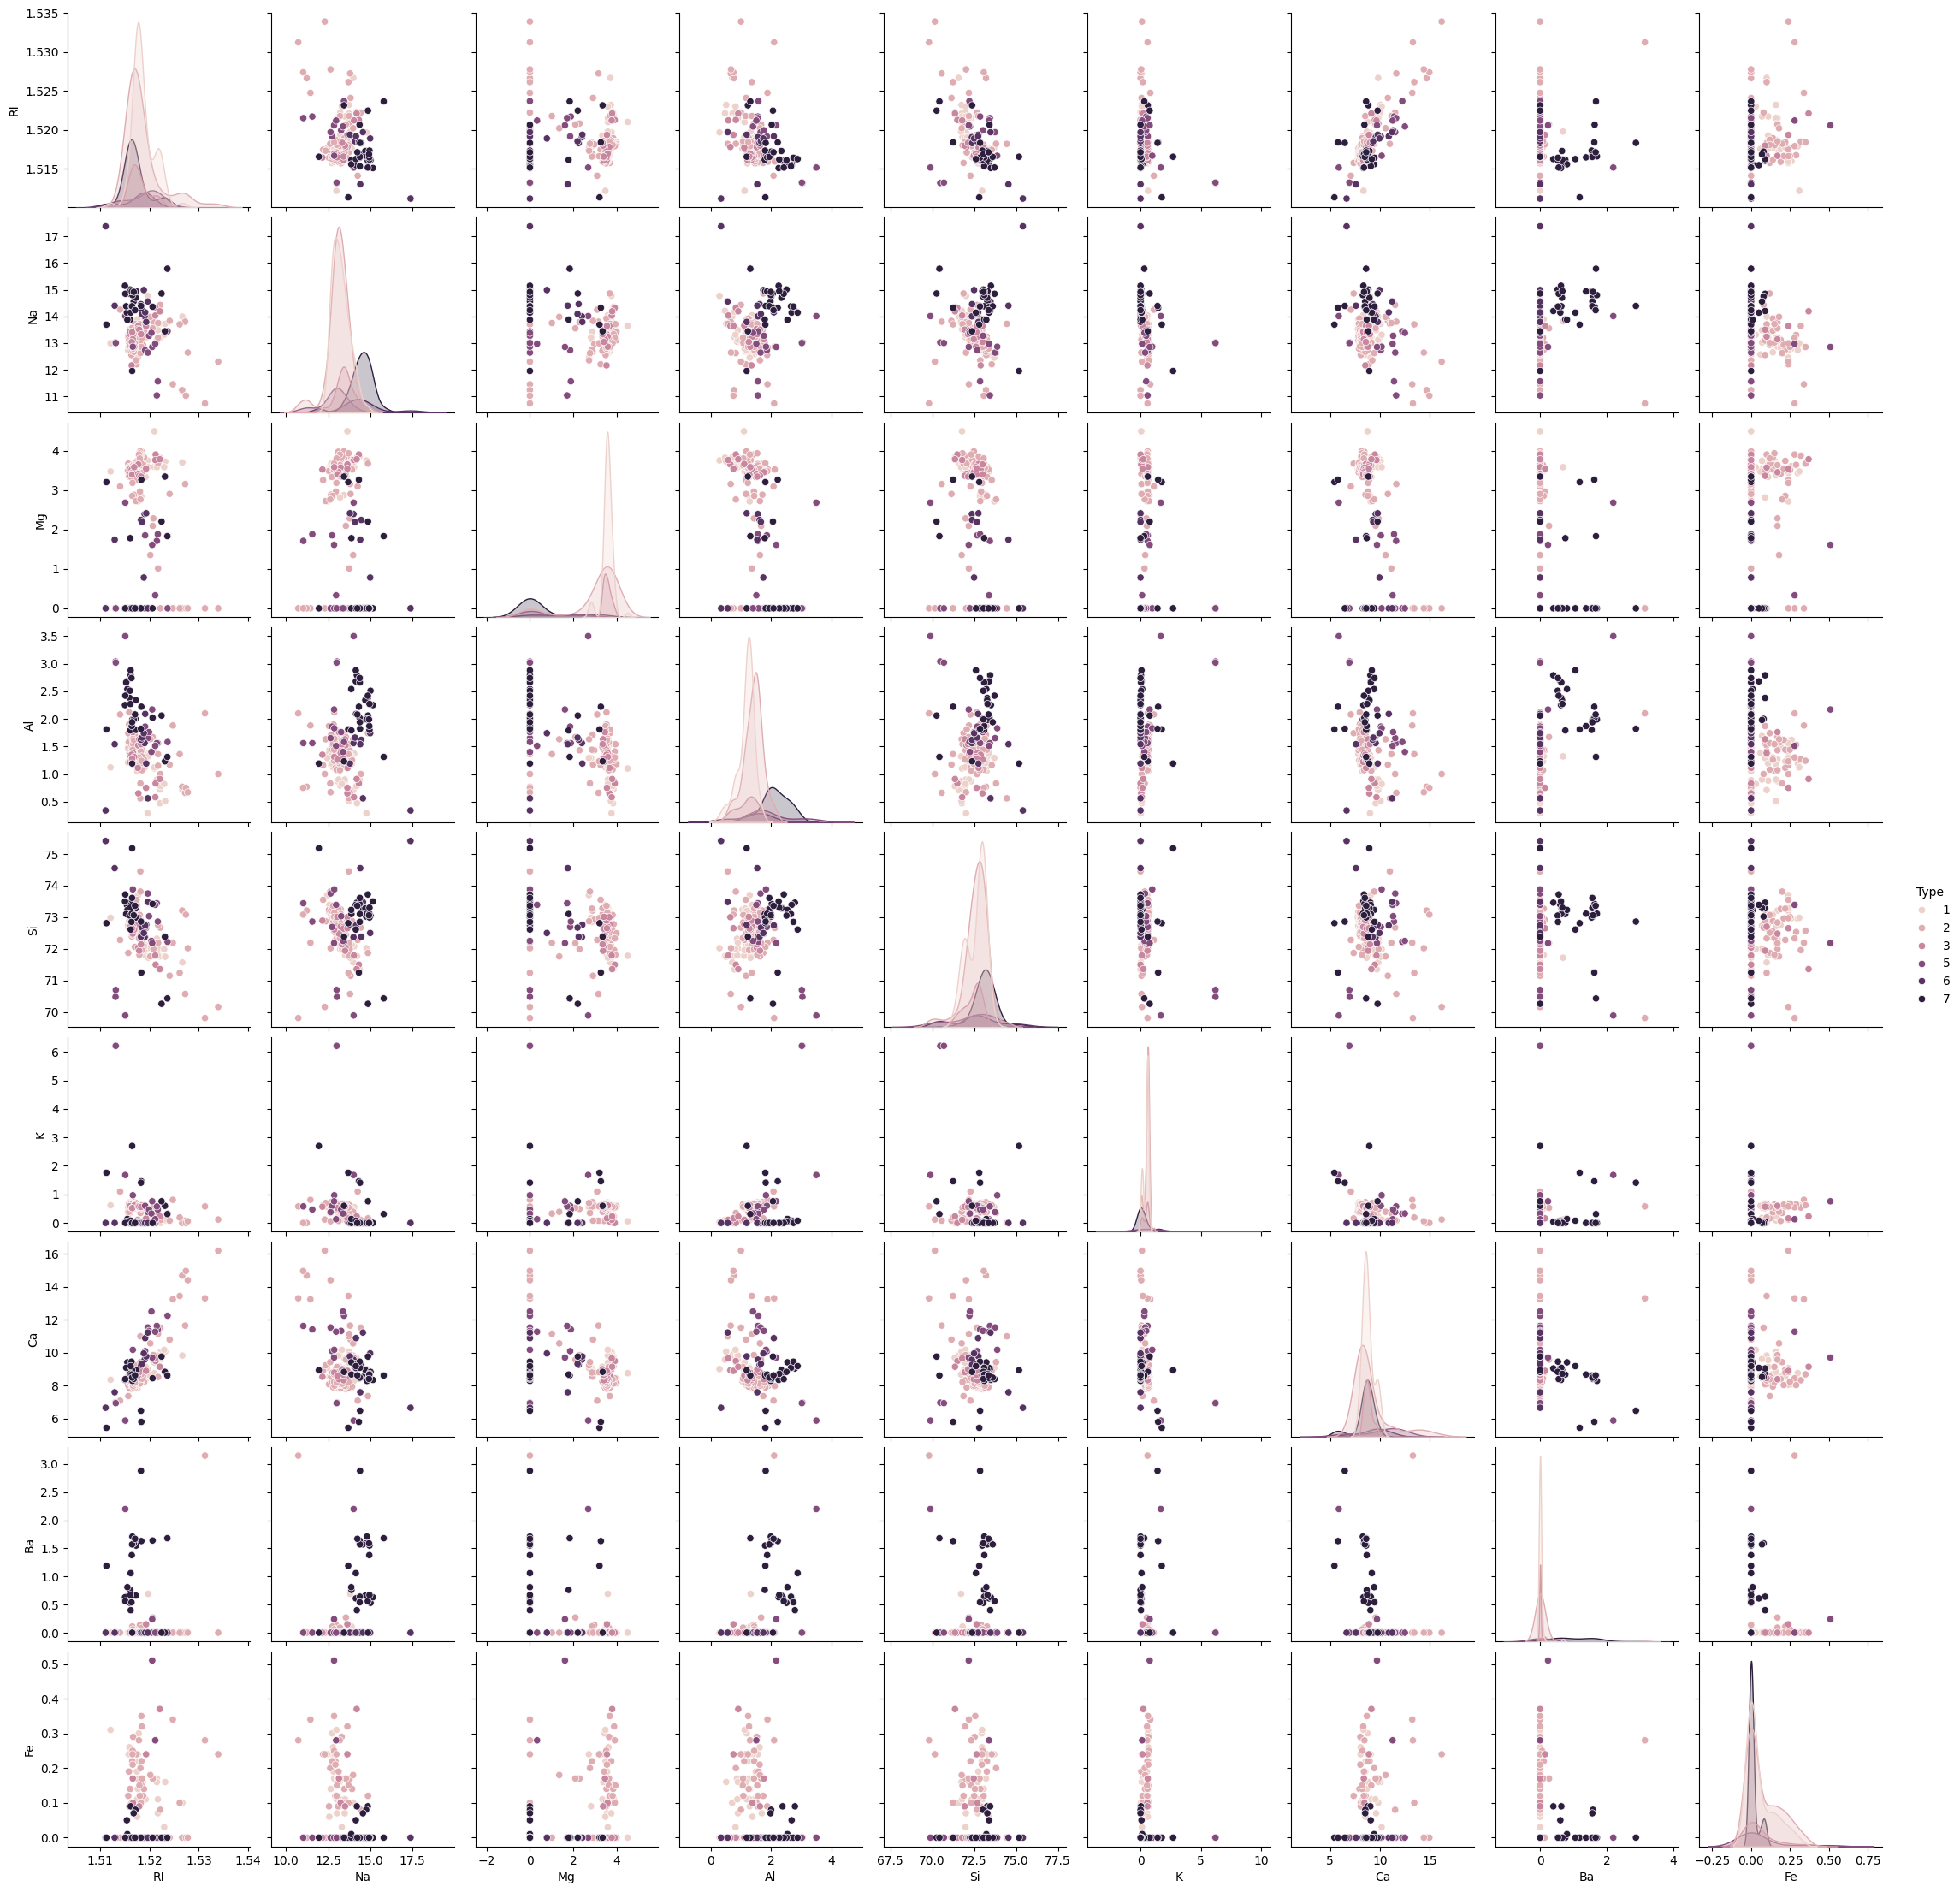

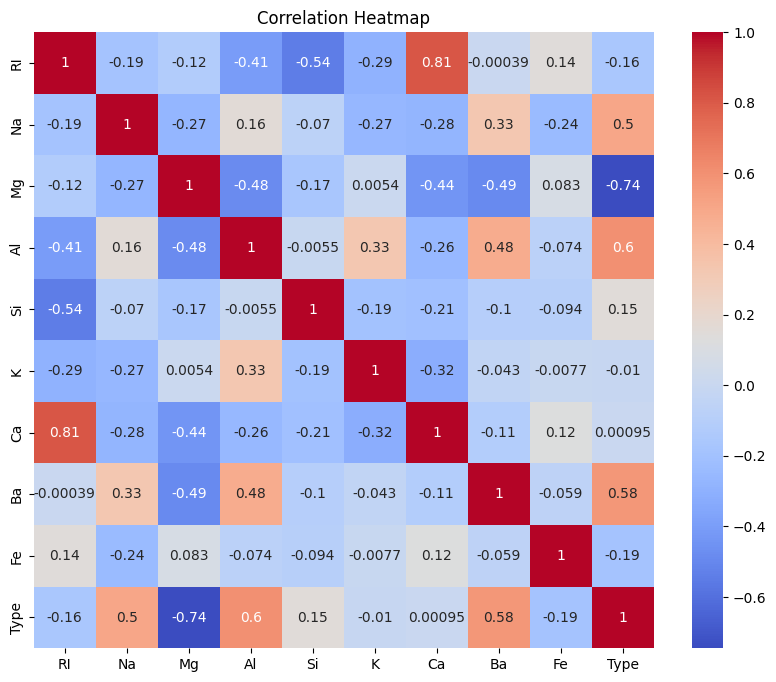

In [15]:
# Histogram for all features
data.hist(bins=15, figsize=(15,10))
plt.suptitle("Histograms of Features")
plt.show()

# Boxplot for detecting outliers
plt.figure(figsize=(12,6))
sns.boxplot(data=data)
plt.title("Boxplot for Outlier Detection")
plt.show()

# Pairplot to see relationships
sns.pairplot(data, hue='Type')
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [16]:
X = data.drop('Type', axis=1)
y = data['Type']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3.4 Handle Imbalance using SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

print("\nClass distribution after SMOTE:")
print(pd.Series(y_res).value_counts())



Class distribution after SMOTE:
Type
1    76
2    76
3    76
5    76
6    76
7    76
Name: count, dtype: int64



Random Forest Model Accuracy: 0.9239130434782609

Classification Report:
               precision    recall  f1-score   support

           1       0.87      0.76      0.81        17
           2       0.85      0.89      0.87        19
           3       0.83      1.00      0.91        10
           5       1.00      1.00      1.00        14
           6       1.00      1.00      1.00        14
           7       1.00      0.94      0.97        18

    accuracy                           0.92        92
   macro avg       0.93      0.93      0.93        92
weighted avg       0.93      0.92      0.92        92



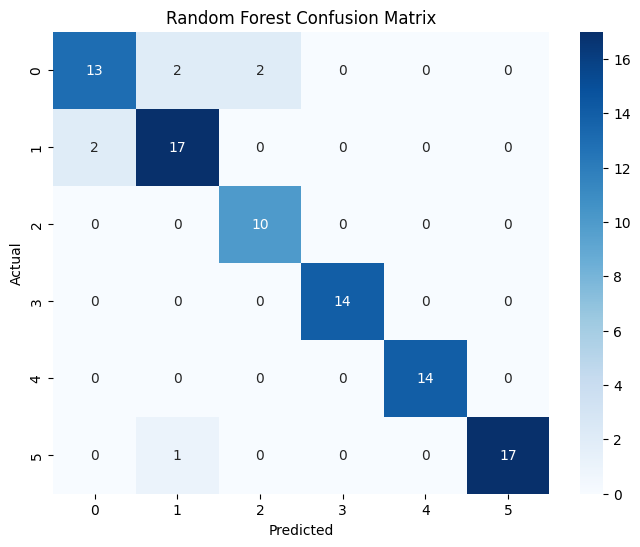

In [17]:
# 4. Random Forest Model Implementation
# -------------------------------

# 4.1 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# 4.2 Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4.3 Predictions
y_pred = rf_model.predict(X_test)

# 4.4 Evaluation
print("\nRandom Forest Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:


# Bagging Classifier (updated parameter name)
bag_model = BaggingClassifier(estimator=RandomForestClassifier(), n_estimators=50, random_state=42)
bag_model.fit(X_train, y_train)
y_bag = bag_model.predict(X_test)
print("\nBagging Model Accuracy:", accuracy_score(y_test, y_bag))

# Boosting using Gradient Boosting
boost_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
boost_model.fit(X_train, y_train)
y_boost = boost_model.predict(X_test)
print("\nBoosting (Gradient Boosting) Model Accuracy:", accuracy_score(y_test, y_boost))



Bagging Model Accuracy: 0.9456521739130435

Boosting (Gradient Boosting) Model Accuracy: 0.9456521739130435


# Additional Notes:



1. Explain Bagging and Boosting methods. How is it different from each other.
Bagging (Bootstrap Aggregating)

Bagging is an ensemble learning technique where multiple models are trained independently on different random subsets of the training data.

Each subset is created by sampling with replacement (bootstrapping) from the original dataset.

The predictions of all models are combined using majority voting (for classification) or averaging (for regression).

Purpose: Reduces variance and prevents overfitting, improving model stability.

Example: Random Forest is a bagging-based algorithm.

Boosting

Boosting is an ensemble learning technique where models are trained sequentially, and each new model tries to correct the errors of the previous models.

Misclassified samples from earlier models are given higher weights, so the next model focuses more on them.

The final prediction is obtained by combining all models (weighted sum or voting).

Purpose: Reduces bias and improves overall model accuracy.

Example: AdaBoost, Gradient Boosting, XGBoost.

Differences Between Bagging and Boosting

The main difference is in their training approach: bagging trains models independently and in parallel, while boosting trains models sequentially, with each model dependent on the previous ones. Bagging treats all samples equally, whereas boosting gives more focus to misclassified samples. Bagging primarily reduces variance, while boosting primarily reduces bias. Bagging is less prone to overfitting, whereas boosting can overfit if too many models are used. Finally, the combination method differs: bagging uses simple majority voting or averaging, while boosting combines predictions in a weighted manner.

2. Explain how to handle imbalance in the data.

Handling Imbalanced Data

Imbalanced data occurs when the number of samples in different classes is not equal, with one class having significantly more samples than others. This can cause machine learning models to be biased toward the majority class, leading to poor performance on minority classes.

Ways to Handle Imbalanced Data

Oversampling – Increase the number of samples in the minority class. Techniques like SMOTE (Synthetic Minority Oversampling Technique) create synthetic examples of the minority class to balance the dataset.

Undersampling – Reduce the number of samples in the majority class by randomly removing some data points to achieve balance.

Class Weights – Assign higher weights to minority classes during model training so that the model gives more importance to them.

Combination Methods – Use both oversampling for minority classes and undersampling for majority classes for better balance.

Evaluation Metrics – Use metrics like Precision, Recall, F1-score, or ROC-AUC instead of accuracy to properly evaluate model performance on imbalanced datasets.